# PCA och KMeans

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
wine = load_wine(as_frame=True)

X = wine.data
y_true = wine.target

# print(wine.DESCR)
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [9]:
print("Shape:", X.shape)
X.info()
display(X.describe().T)

Shape: (178, 13)
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtyp

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,7.943708e-15,1.002821,-2.434235,-0.788245,0.061000,0.836129,2.259772
malic_acid,178.0,3.592632e-16,1.002821,-1.432983,-0.658749,-0.423112,0.669793,3.109192
ash,178.0,-4.066660e-15,1.002821,-3.679162,-0.572122,-0.023821,0.698109,3.156325
alcalinity_of_ash,178.0,-7.983626e-17,1.002821,-2.671018,-0.689137,0.001518,0.602088,3.154511
magnesium,178.0,-7.983626e-17,1.002821,-2.088255,-0.824415,-0.122282,0.509638,4.371372


In [13]:
display(pd.DataFrame({
    "mean": X_scaled_df.mean().round(3),
    "std": X_scaled_df.std(ddof=0).round(3)
}))

,mean,std
alcohol,0.0,1.0
malic_acid,0.0,1.0
ash,-0.0,1.0
alcalinity_of_ash,-0.0,1.0
magnesium,-0.0,1.0
total_phenols,-0.0,1.0
flavanoids,0.0,1.0
nonflavanoid_phenols,-0.0,1.0
proanthocyanins,-0.0,1.0
color_intensity,-0.0,1.0


## PCA

In [14]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_ratio = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

print("explained variance ratio (first 10):", np.round(explained_ratio[:10], 4))
print("Cumulative explained variance (first 10):", np.round(cum_explained[:10], 4))

explained variance ratio (first 10): [0.362  0.1921 0.1112 0.0707 0.0656 0.0494 0.0424 0.0268 0.0222 0.0193]
Cumulative explained variance (first 10): [0.362  0.5541 0.6653 0.736  0.8016 0.851  0.8934 0.9202 0.9424 0.9617]


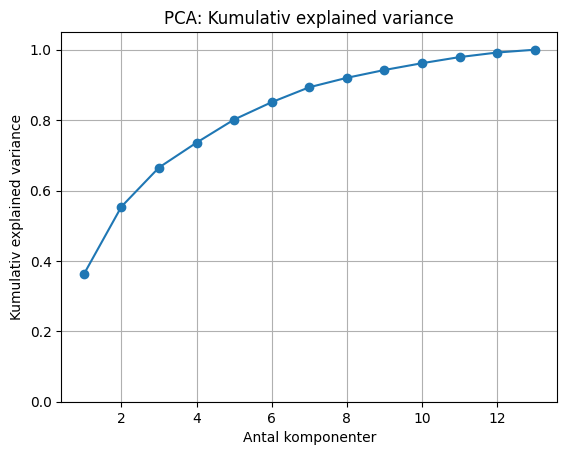

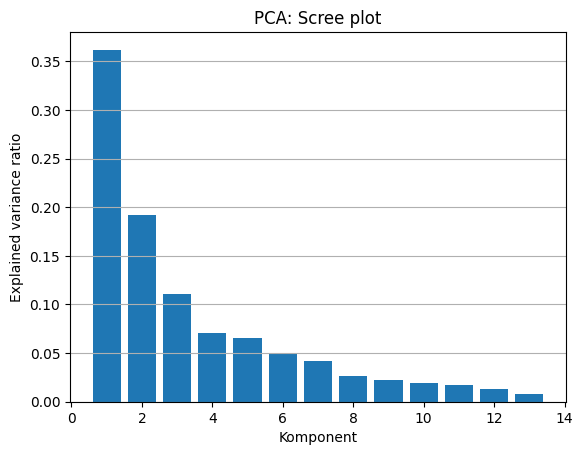

In [15]:
plt.figure()
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker="o")
plt.xlabel("Antal komponenter")
plt.ylabel("Kumulativ explained variance")
plt.title("PCA: Kumulativ explained variance")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

plt.figure()
plt.bar(range(1, len(explained_ratio) + 1), explained_ratio)
plt.xlabel("Komponent")
plt.ylabel("Explained variance ratio")
plt.title("PCA: Scree plot")
plt.grid(True, axis="y")
plt.show()

In [27]:
n_95 = int(np.argmax(cum_explained >= 0.95) + 1)
print("Min components for >= 95% explained variance", n_95)

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_95 = PCA(n_components=n_95)
X_pca_95 = pca_95.fit_transform(X_scaled)


print("Explained variance (PC1, PC2):", np.round(pca_2.explained_variance_ratio_, 4))
print("Total explained variance (2 components):", np.round(float(pca_2.explained_variance_ratio_.sum()),4))

Min components for >= 95% explained variance 10
Explained variance (PC1, PC2): [0.362  0.1921]
Total explained variance (2 components): 0.5541


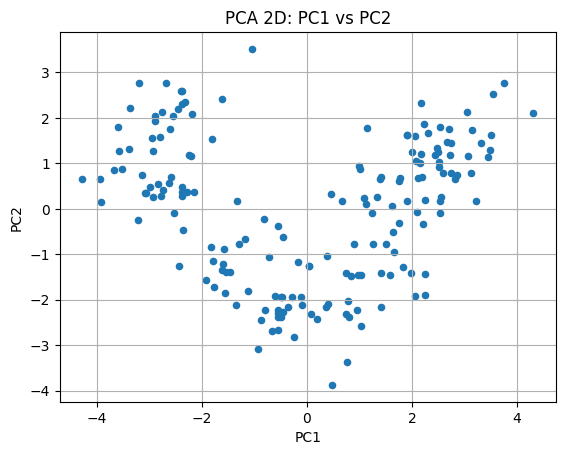

In [29]:
plt.figure()
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D: PC1 vs PC2")
plt.grid(True)
plt.show()

## PCA Utan scaling

Explained variance (raw, PC1 & PC2): [0.9981 0.0017]
Total explained variance (raw, 2 components): 0.9998


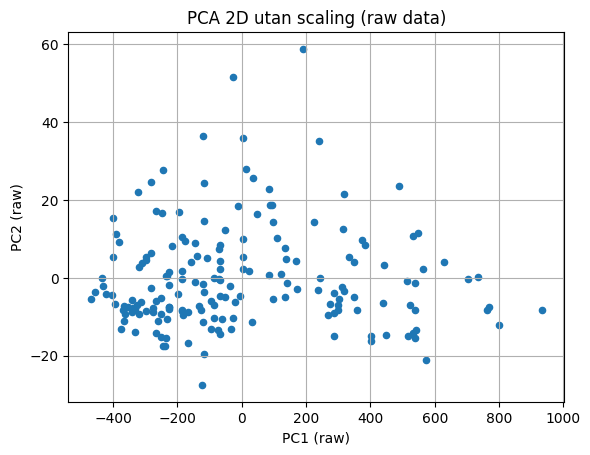

In [41]:
pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X)

print("Explained variance (raw, PC1 & PC2):", np.round(pca_raw.explained_variance_ratio_, 4))
print("Total explained variance (raw, 2 components):", np.round(float(pca_raw.explained_variance_ratio_.sum()),4))

plt.figure()
plt.scatter(X_pca_raw[:,0], X_pca_raw[:,1], s=20)
plt.xlabel("PC1 (raw)")
plt.ylabel("PC2 (raw)")
plt.title("PCA 2D utan scaling (raw data)")
plt.grid(True)
plt.show()

## Kmeans utan scaling

,K,inertia_raw,silhouette_raw
0,2,4.543750e+06,0.656854
1,3,2.370690e+06,0.571138
2,4,1.331903e+06,0.562032
3,5,9.163792e+05,0.548999
4,6,6.473260e+05,0.565641
5,7,4.123038e+05,0.562168
6,8,3.232116e+05,0.540682
7,9,2.731543e+05,0.524797
8,10,2.179368e+05,0.521272


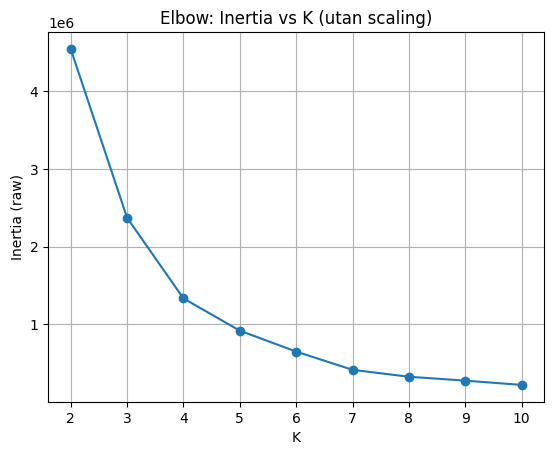

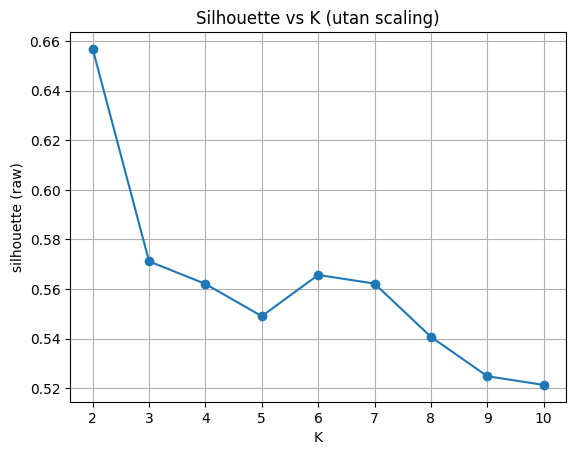

In [43]:
inertias_raw = []
sil_raw = []
K_range = range(2, 11)

for K in K_range:
    km_raw = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels_raw = km_raw.fit_predict(X)
    inertias_raw.append(km_raw.inertia_)
    sil_raw.append(silhouette_score(X, labels_raw))

results_raw = pd.DataFrame({
    "K": list(K_range),
    "inertia_raw": inertias_raw,
    "silhouette_raw": sil_raw
})

display(results_raw)

plt.figure()
plt.plot(list(K_range), inertias_raw, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia (raw)")
plt.title("Elbow: Inertia vs K (utan scaling)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(results_raw["K"], results_raw["silhouette_raw"], marker="o")
plt.xlabel("K")
plt.ylabel("silhouette (raw)")
plt.title("Silhouette vs K (utan scaling)")
plt.grid(True)
plt.show()

## KMeans

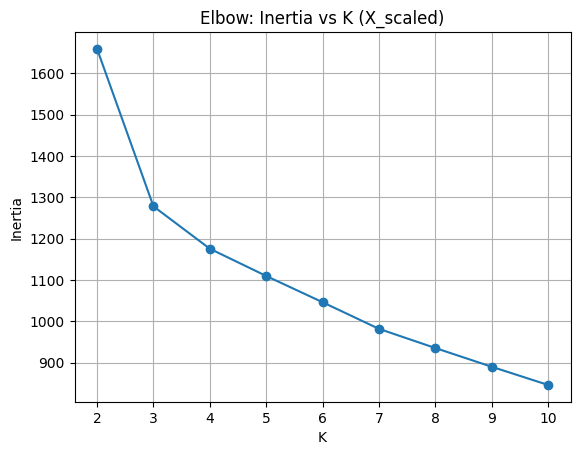

In [30]:
inertias = []
K_range = range(2, 11)

for K in K_range:
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)


plt.figure()
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow: Inertia vs K (X_scaled)")
plt.grid(True)
plt.show()

,K,inertia,silhouette
0,2,1658.758852,0.259317
1,3,1277.928489,0.284859
2,4,1175.428333,0.260170
3,5,1109.512739,0.201619
4,6,1046.002333,0.237167
5,7,981.595233,0.203628
6,8,935.201211,0.157014
7,9,889.892911,0.149882
8,10,845.895237,0.143638


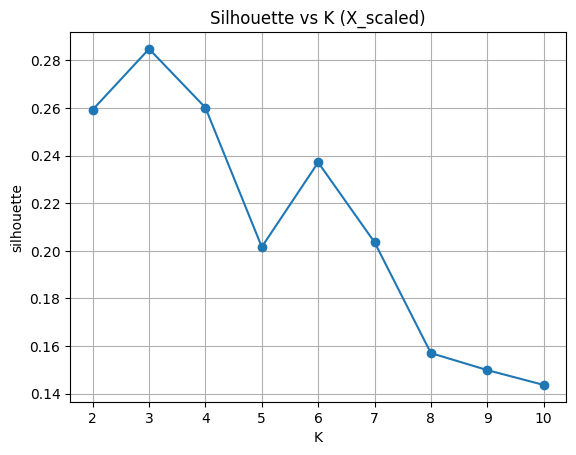

In [31]:
results = []

for K in range(2, 11):
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    results.append({ "K": K, "inertia": km.inertia_, "silhouette": sil })

results_df = pd.DataFrame(results)
display(results_df)

plt.figure()
plt.plot(results_df["K"], results_df["silhouette"], marker="o")
plt.xlabel("K")
plt.ylabel("silhouette")
plt.title("Silhouette vs K (X_scaled)")
plt.grid(True)
plt.show()

In [32]:
K_final = 3
kmeans_final = KMeans(n_clusters=K_final, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

print(pd.Series(cluster_labels).value_counts().sort_index())

0    65
1    51
2    62
Name: count, dtype: int64


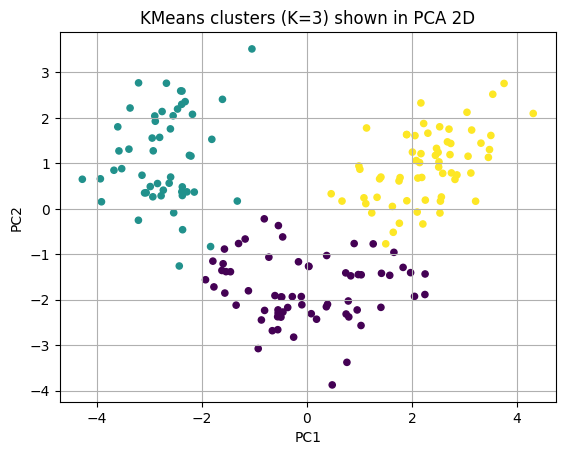

In [33]:
plt.figure()
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=cluster_labels, s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters (K=3) shown in PCA 2D")
plt.grid(True)
plt.show()

In [34]:
X_with_clusters = X.copy()
X_with_clusters["cluster"] = cluster_labels
profile_orig = X_with_clusters.groupby("cluster").mean()
display(profile_orig.iloc[:, :8])

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols
cluster,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097


In [35]:
profile_scaled = X_scaled_df.copy()
profile_scaled["cluster"] = cluster_labels
profile_scaled = profile_scaled.groupby("cluster").mean()
display(profile_scaled.iloc[:, :8])

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols
cluster,,,,,,,,
0,-0.926072,-0.394042,-0.494517,0.170602,-0.491712,-0.075983,0.020813,-0.033534
1,0.164907,0.871547,0.186898,0.524367,-0.075473,-0.979330,-1.215248,0.726064
2,0.835232,-0.303810,0.364706,-0.610191,0.577587,0.885237,0.977820,-0.562090


In [36]:
ct = pd.crosstab(pd.Series(cluster_labels, name="cluster"),
                 pd.Series(y_true, name="true_class"))

display(ct)

true_class,0,1,2
cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


In [39]:
X_demo = X.copy()

X_demo["alcohol_level"] = pd.cut(
    X_demo["alcohol"],
    bins=[-np.inf,
          X_demo["alcohol"].quantile(0.33),
          X_demo["alcohol"].quantile(0.66),
          np.inf],
    labels=["low", "medium", "high"]
)


X_demo[["alcohol", "alcohol_level"]].head()

,alcohol,alcohol_level
0,14.23,high
1,13.20,medium
2,13.16,medium
3,14.37,high
4,13.24,medium


In [40]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat_ohe = ohe.fit_transform(X_demo[["alcohol_level"]])

print("One-hot columns:", ohe.get_feature_names_out(["alcohol_level"]))
print("One-hot shape:", X_cat_ohe.shape)

pd.DataFrame(X_cat_ohe, columns=ohe.get_feature_names_out(["alcohol_level"])).head(10)

One-hot columns: ['alcohol_level_high' 'alcohol_level_low' 'alcohol_level_medium']
One-hot shape: (178, 3)


,alcohol_level_high,alcohol_level_low,alcohol_level_medium
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0
6,1.0,0.0,0.0
7,1.0,0.0,0.0
8,1.0,0.0,0.0
9,1.0,0.0,0.0
